# Test simulator cases

Oreonspy foresees four cases based on the cavity round-trip time, required sampling frequency and chosen simulator accuracy for decaing electric field. For most of the required sampling frequency it is required an approximation to the closest computable frequency.

```real_f_calc()``` implements the algorithm used in oreonspy to choose between cases. In the second part of the notebook we attempt to test the approximation of the sampling frequency produced by the algorithm.

The most important variable in the algorithm is the number of roundtrips a photon will make inside the cavity in the timelap between two consecutive simulator samples ```N```.  The sampling frequency appoximation arises from the fact that ```N``` must be integer.

If ```N``` is smaller than one, the simulation is not possible using the difference equation. In this case, the simulator creates several simulators shifted in phase in order to satisfy the required sampling frequency.

The algorithm contains one constant (```N_epsilon```) which must be optimized for the best frequency approximation.\
Goal: Optimize ```N_epsilon```.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def number_of_2T_chains(N_pre):
    #return int(np.ceil(1.0 / N_pre))
    return 1 if N_pre < 1 else int(np.round(N_pre))


def round_for_inverse_curve(N_pre):
    N_pre_arr = np.asarray(N_pre, dtype=float)

    k0 = np.floor(N_pre_arr)
    b = 2 * k0 * (k0 + 1) / (2 * k0 + 1)
    k = np.where(N_pre_arr < b, k0, k0 + 1).astype(int)

    # Preserve scalar return type for scalar input
    if np.isscalar(N_pre):
        return int(k), float(b)
    return k, b


def real_f_calc(N_pre, N_epsilon, _2T, desired_f_calc, N_eff=1000):
    """
    Simulator case algorithm from cavity.simulation() in oreonspy 3.2.3.
    
    N_pre = 1./(desired_f_calc * _2T)
    N_epsilon -- parameter of the algorithm
    _2T -- 2 times the cavity round trip time
    desired_f_calc -- the desired sampling frequency
    N_eff -- mean number of photon bounces in the cavity
    """
    N = 1

    _N_eff_factor = 2

    case = 0
    
    if N_pre < (1.0 - N_epsilon):
        case = 0

        #logger.info("2T x times bigger then Theta. (x is integer)")
        number_of_2T_chains = int(np.ceil(1.0 / N_pre))  # Original oreons function
        number_of_2T_chains = int(np.round(1.0 / N_pre))  # Proposed alternative

        f_calc = number_of_2T_chains / _2T
        Theta = 1.0 / f_calc
        #logger.warning("Warning: approximated f_calc to: {0:.2f}".format(f_calc))
        #logger.warning("Number of chains: {0}".format(number_of_2T_chains))

    elif N_pre < (1.0 + N_epsilon):
        case = 1

        #logger.info("2T comparable with Theta so N becomes 1")
        f_calc = 1.0 / _2T
        Theta = _2T
        #logger.warning("Warning: approximated f_calc to: {0:.2f}".format(f_calc))

    else:
        N_max = _N_eff_factor * N_eff
        #logger.debug("N_max: {0}".format(N_max))
        if N_pre > N_max:
            case = 2

            #logger.info("N times Cavity decay time shorter than the sampling period")
            N = N_max
            f_calc = desired_f_calc  # In this case desired f_calc is exactly computed.
            Theta = 1.0 / f_calc

            partial_Theta = True
        else:
            case = 3

            #logger.info("N times Cavity decay time longer than the sampling period")
            N = int(np.round(N_pre+0.166))  # Original oreons function
            #N = int(np.ceil(N_pre))  # Proposed alternative
            #N = int(np.round(N_pre))  # Current oreons
            Theta = _2T * N
            f_calc = 1.0 / Theta
    

    if N_pre < 1:
        number_of_2T_chains = int(np.round(1.0 / N_pre))
        f_calc = number_of_2T_chains*(1/_2T)
        N = 1  # Initlized to one in the constructor.
    else:
        N_max = _N_eff_factor * N_eff
        if N_pre > N_max:
            N = N_max
            f_calc = desired_f_calc  # In this case desired f_calc is exactly computed.
            partial_Theta = True
        else:
            #number_of_2T_chains = 1  # Initlized to one in the constructor.
            N = round_for_inverse_curve(N_pre)[0]
            f_calc = 1.0/(N*_2T)  # in Hz

    Theta = 1.0 / f_calc  # in Seconds

    # TODO: solve partial Theta case
            
    return f_calc, Theta, case, N

Unique quantized values: [1 2 3]
Monotonic non-decreasing: True


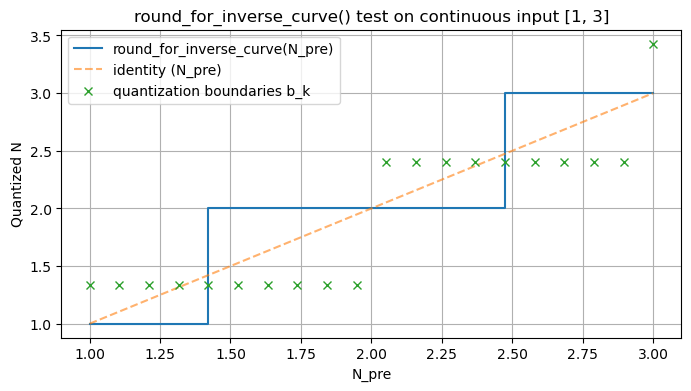

In [25]:
# Test round_for_inverse_curve() on a continuous interval N_pre in [1, 3]
N_pre_test = np.linspace(1.0001, 3.0, 20)
Nq_test, b_test = round_for_inverse_curve(N_pre_test)

# Basic checks
print("Unique quantized values:", np.unique(Nq_test))
print("Monotonic non-decreasing:", np.all(np.diff(Nq_test) >= 0))

# Plot quantization behavior
plt.figure(figsize=(8, 4))
plt.step(N_pre_test, Nq_test, where="post", label="round_for_inverse_curve(N_pre)")
plt.plot(N_pre_test, N_pre_test, "--", alpha=0.6, label="identity (N_pre)")
plt.plot(N_pre_test, b_test, "x", label="quantization boundaries b_k")    
plt.xlabel("N_pre")
plt.ylabel("Quantized N")
plt.title("round_for_inverse_curve() test on continuous input [1, 3]")
plt.grid(True)
plt.legend()
plt.show()

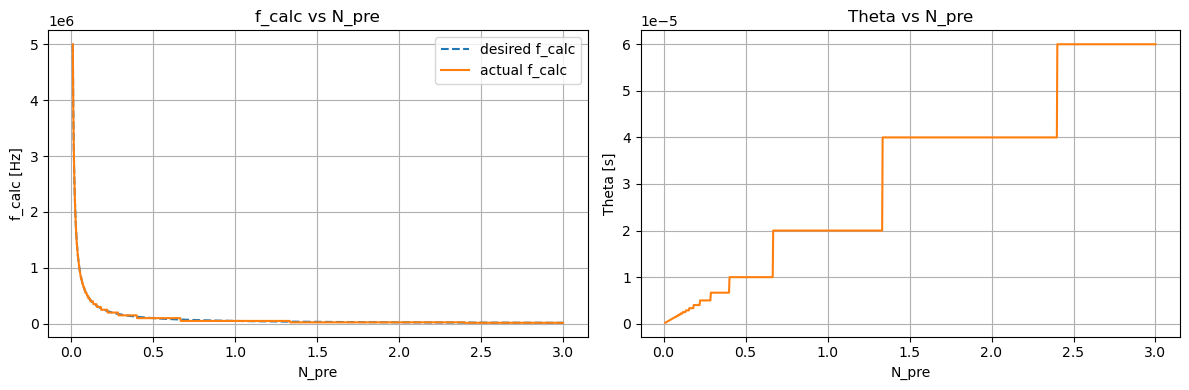

In [26]:
# Testbench for real_f_calc(): sweep N_pre and plot f_calc and Theta

N_pre_sweep = np.linspace(0.01, 3.0, 1000)

desired_f_sweep = 1.0 / (N_pre_sweep * _2T)
f_calc_sweep = np.empty_like(N_pre_sweep)
Theta_sweep = np.empty_like(N_pre_sweep)

for i, N_pre in enumerate(N_pre_sweep):
    f_calc, Theta, _, _ = real_f_calc(
        N_pre=N_pre,
        N_epsilon=N_epsilon,
        _2T=_2T,
        desired_f_calc=desired_f_sweep[i],
        N_eff=my_N_eff,
    )
    f_calc_sweep[i] = f_calc
    Theta_sweep[i] = Theta

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(N_pre_sweep, desired_f_sweep, label="desired f_calc", linestyle="--")
ax[0].plot(N_pre_sweep, f_calc_sweep, label="actual f_calc")
ax[0].set_xlabel("N_pre")
ax[0].set_ylabel("f_calc [Hz]")
ax[0].set_title("f_calc vs N_pre")
ax[0].grid(True)
ax[0].legend()
#ax[0].set_ylim(0, 5.)

ax[1].plot(N_pre_sweep, Theta_sweep, color="tab:orange")
ax[1].set_xlabel("N_pre")
ax[1].set_ylabel("Theta [s]")
ax[1].set_title("Theta vs N_pre")
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Analyse the choice of the simulator case and the sampling frequency approximation

For an arbitrarily chosen cavity, plot the number of simulators involved (```number_of_2T_chains```).

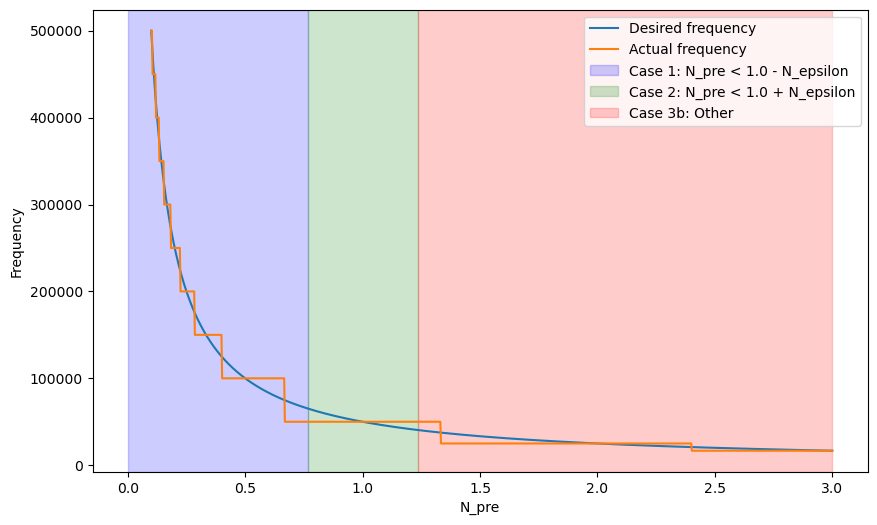

In [27]:
import matplotlib.pyplot as plt

# Define N_epsilon
N_epsilon = 0.234
_2T = 6000./3e8  # 2 times the cavity round trip time in seconds (for a 3000 m cavity)
my_N_eff = 10000

# Generate N_pre values
#N_pre_values = np.logspace(-1, 1, 1000)
N_pre_values = np.linspace(0.1, 3, 1000)

# Compute number_of_2T_chains for each N_pre
chains_values = [number_of_2T_chains(N_pre) for N_pre in N_pre_values]

# Compute f_calc and Theta for each N_pre
desired_f_calc_values = []
actual_f_calc_values = []
Theta_values = []
case_values = []
N_values = []
for N_pre in N_pre_values:
    desired_f_calc = 1./(N_pre * _2T)
    actual_f_calc, Theta, case, N = real_f_calc(N_pre, N_epsilon, _2T=_2T, desired_f_calc=desired_f_calc, N_eff=my_N_eff)
    desired_f_calc_values.append(desired_f_calc)
    case_values.append(case)
    actual_f_calc_values.append(actual_f_calc)
    Theta_values.append(Theta)
    N_values.append(N)

# Sanity check
assert all(isinstance(N, int) for N in N_values), "Not all elements in N_values are integers."

# Convert to numpy arrays for easier manipulation
desired_f_calc_values = np.array(desired_f_calc_values)
actual_f_calc_values = np.array(actual_f_calc_values)
Theta_values = np.array(Theta_values)

plt.figure(figsize=(10, 6))
plt.plot(N_pre_values, desired_f_calc_values, label="Desired frequency")
plt.plot(N_pre_values, actual_f_calc_values, label="Actual frequency")

# Add vertical color regions
plt.axvspan(0, 1.0 - N_epsilon, color='blue', alpha=0.2, label='Case 1: N_pre < 1.0 - N_epsilon')
plt.axvspan(1.0 - N_epsilon, 1.0 + N_epsilon, color='green', alpha=0.2, label='Case 2: N_pre < 1.0 + N_epsilon')
plt.axvspan(1.0 + N_epsilon, max(N_pre_values), color='red', alpha=0.2, label='Case 3{0}'.format("a: N_pre > N_max" if case == 2 else "b: Other"))

plt.xlabel("N_pre")
plt.ylabel("Frequency")
plt.legend()

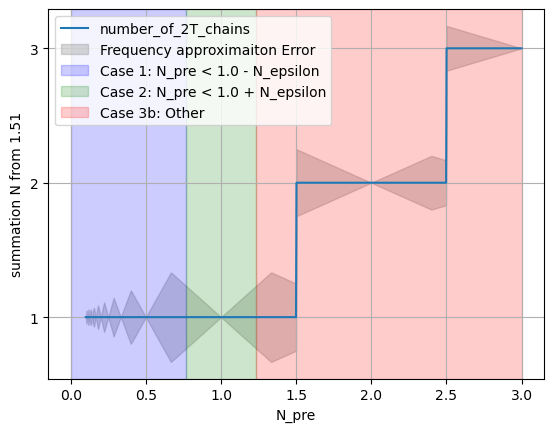

In [28]:

# Calculate the absolute error
f_calc_accuracy = np.abs(actual_f_calc_values - desired_f_calc_values) / desired_f_calc_values
#f_calc_accuracy = np.abs(actual_f_calc_values - desired_f_calc_values)

# Try to calculate normalized time-step relative error
N_accuracy = np.abs(1/actual_f_calc_values - 1/desired_f_calc_values) / (1/desired_f_calc_values)
#f_calc_accuracy = N_accuracy

# Plot the results
plt.plot(N_pre_values, chains_values, label='number_of_2T_chains')


# Plot the error area
plt.fill_between(N_pre_values, 
                 [value - error for value, error in zip(chains_values, f_calc_accuracy)], 
                 [value + error for value, error in zip(chains_values, f_calc_accuracy)], 
                 color='gray', alpha=0.3, label='Frequency approximaiton Error')

# Add vertical color regions
plt.axvspan(0, 1.0 - N_epsilon, color='blue', alpha=0.2, label='Case 1: N_pre < 1.0 - N_epsilon')
plt.axvspan(1.0 - N_epsilon, 1.0 + N_epsilon, color='green', alpha=0.2, label='Case 2: N_pre < 1.0 + N_epsilon')
plt.axvspan(1.0 + N_epsilon, max(N_pre_values), color='red', alpha=0.2, label='Case 3{0}'.format("a: N_pre > N_max" if case == 2 else "b: Other"))

# Add labels and title
plt.xlabel('N_pre')
plt.ylabel('summation N from 1.51')
plt.yticks(range(min(chains_values), max(chains_values) + 1))
#plt.title('Number of 2T Chains vs N_pre')

# Add legend and grid
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# Analyse sampling frequency approximation accuracy

More suitable plot depicts directly the approximation accuracy.

At this point the parameter ```N_epsilon``` has been already optimized. It was initially 0,1 but it seems that the value of 0,25 assures better approximation.

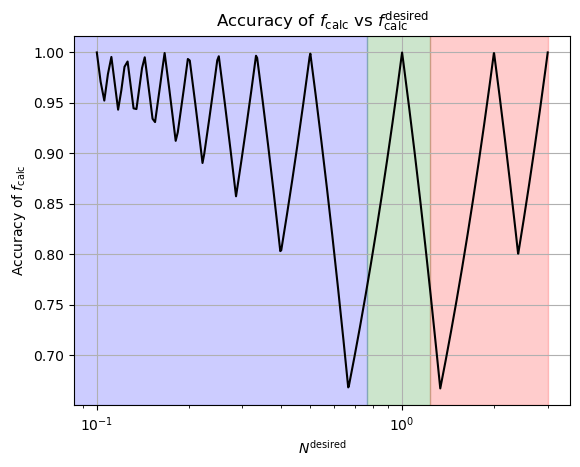

In [29]:
plt.plot(N_pre_values, 1-f_calc_accuracy, label='f_calc_accuracy', color='black')
#plt.plot(N_pre_values, case_values, label='case', color='orange')

# Add vertical color regions
plt.axvspan(0, 1.0 - N_epsilon, color='blue', alpha=0.2, label='Case 1: $N^\mathrm{desired}$ < 1.0 - $\epsilon_N$')
plt.axvspan(1.0 - N_epsilon, 1.0 + N_epsilon, color='green', alpha=0.2, label='Case 2: $N^\mathrm{desired}$ < 1.0 + $\epsilon_N$')
plt.axvspan(1.0 + N_epsilon, max(N_pre_values), color='red', alpha=0.2, label='Case 3{0}'.format("a: $N^\mathrm{desired}$ > N_max" if case == 2 else "b: other"))

plt.xscale('log')
#plt.ylim(0.999, 1.001)


# Add labels and title
plt.xlabel('$N^\mathrm{desired}$')
plt.ylabel('Accuracy of $f_\mathrm{calc}$')
plt.title('Accuracy of $f_\mathrm{calc}$ vs $f^\mathrm{desired}_\mathrm{calc}$')


# Add legend and grid
#plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# Calculate average accuracy in the range of ```N_pre```

In [ ]:
# Integrate 1 - f_calc_accuracy
integral = np.trapz(1 - f_calc_accuracy, dx=(N_pre_values[1] - N_pre_values[0])) / N_pre_values[-1]
print(f"Normalized integral of (1 - f_calc_accuracy): {integral:.3f}")

## Results

### Case 3a (```partial_theta = False```)

| Case 1 function | Case 3 function | ```N_epsilon``` | Case 3 rounding correction | Normalized integrated ```1 - f_calc_accuracy``` | Notes                           |
|-----------------|-----------------|-----------------|----------------------------|-------------------------------------------------|---------------------------------|
| ```np.ceil()``` | ```round()```   | 0,1             | not used                   | **0,813**                                       | Initial solution                |
| -\|\|-          | -\|\|-          | 0,25            | not used                   | **0,827**                                       | Optimized ```N_epsilon```       |
| ```round()```   | ```round()```   | 0,25            | not used                   | **0,835**                                       | Optimized Case 3 function       |
| ```round()```   | ```round()```   | 0,25            | +0,12                      | **0,840**                                       | Introduced and optimized coefficient in Case 3 |
|                 |                 |                 |                            |                                                 |                                 |